In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/Users/tharmmm/Documents/store_sale_project/store-sales-time-series-forecasting/train.csv")
df.head(20)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [40]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


### Check null value

In [50]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

### Number of unique store

In [17]:
print(np.sort(df["store_nbr"].unique()))
print(f"number of stores : {len(df['store_nbr'].unique())}")

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54]
number of stores : 54


### The number of stuff in store

In [35]:
print(df[df["store_nbr"] == 1]["family"].unique())
print(f"The number of unique family in one store : {len(df[df['store_nbr'] == 1]['family'].unique())}")

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']
The number of unique family in one store : 33


In [41]:
for store, count in df.groupby("store_nbr")["family"].nunique().items():
    print(f"The number of unique family in store {store} : {count}")


The number of unique family in store 1 : 33
The number of unique family in store 2 : 33
The number of unique family in store 3 : 33
The number of unique family in store 4 : 33
The number of unique family in store 5 : 33
The number of unique family in store 6 : 33
The number of unique family in store 7 : 33
The number of unique family in store 8 : 33
The number of unique family in store 9 : 33
The number of unique family in store 10 : 33
The number of unique family in store 11 : 33
The number of unique family in store 12 : 33
The number of unique family in store 13 : 33
The number of unique family in store 14 : 33
The number of unique family in store 15 : 33
The number of unique family in store 16 : 33
The number of unique family in store 17 : 33
The number of unique family in store 18 : 33
The number of unique family in store 19 : 33
The number of unique family in store 20 : 33
The number of unique family in store 21 : 33
The number of unique family in store 22 : 33
The number of uniqu

In [45]:
df.groupby(["store_nbr","family"])["sales"].sum()

store_nbr  family                    
1          AUTOMOTIVE                    5.475000e+03
           BABY CARE                     0.000000e+00
           BEAUTY                        4.056000e+03
           BEVERAGES                     2.673769e+06
           BOOKS                         2.110000e+02
                                             ...     
54         POULTRY                       8.888981e+04
           PREPARED FOODS                1.030900e+05
           PRODUCE                       5.961803e+05
           SCHOOL AND OFFICE SUPPLIES    1.023000e+03
           SEAFOOD                       2.938000e+03
Name: sales, Length: 1782, dtype: float64

### Range of Date

In [47]:
print(f"Number of days : {df['date'].nunique()}")
print(f"Date range : {df['date'].min()} to {df['date'].max()}")


Number of days : 1684
Date range : 2013-01-01 to 2017-08-15


In [48]:
df.groupby("store_nbr")["date"].agg(["min", "max", "nunique"])

,min,max,nunique
store_nbr,,,
1,2013-01-01,2017-08-15,1684
2,2013-01-01,2017-08-15,1684
3,2013-01-01,2017-08-15,1684
4,2013-01-01,2017-08-15,1684
5,2013-01-01,2017-08-15,1684
6,2013-01-01,2017-08-15,1684
7,2013-01-01,2017-08-15,1684
8,2013-01-01,2017-08-15,1684
9,2013-01-01,2017-08-15,1684


### Overall Sales Trend

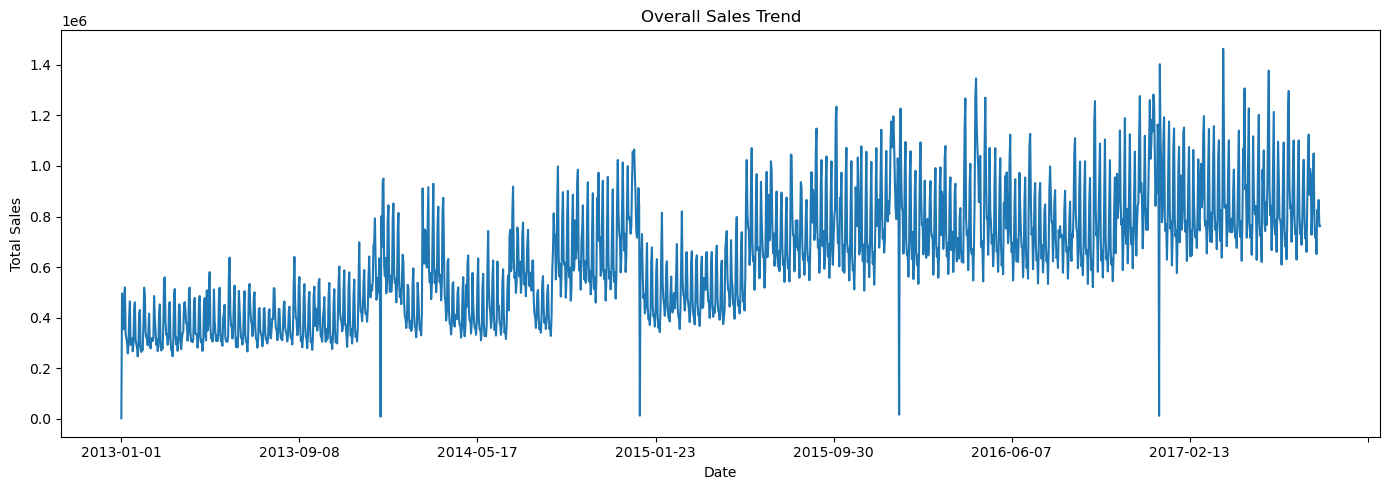

In [54]:
df.groupby("date")["sales"].sum().plot(figsize=(14, 5), title="Overall Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()